In [ ]:
import json
import os
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms


In [34]:
# Configurando hiperparametros.
args = {
    'batch_size': 32,
    'lr_layer3': 1e-5,
    'lr_layer4': 1e-4,
    'lr_fc': 1e-3,
    'num_epochs': 20,
    'weight_decay': 1e-4,
    'seed': 42
}

# Seed global para reprodutibilidade
random.seed(args['seed'])
np.random.seed(args['seed'])
torch.manual_seed(args['seed'])
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(args['seed'])
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Definindo dispositivo de hardware
if torch.cuda.is_available():
    args['device'] = torch.device('cuda')
else:
    args['device'] = torch.device('cpu')

print(args['device'])
print(f"Seed global: {args['seed']}")

cuda
Seed global: 42


In [ ]:
data_transform_treino = transforms.Compose([
                                    transforms.RandomHorizontalFlip(p=0.5),
                                    transforms.RandomRotation(10),
                                    transforms.Resize(224),
                                    transforms.ToTensor(),
                                    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                                          std=[0.229, 0.224, 0.225])
                  ])

data_transform = transforms.Compose([
                                     transforms.Resize(224),
                                     transforms.ToTensor(),
                                     transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                                          std=[0.229, 0.224, 0.225])
                  ])

train_set_aug = datasets.ImageFolder(root='../data/fer2013/train', transform=data_transform_treino)
train_set_eval = datasets.ImageFolder(root='../data/fer2013/train', transform=data_transform)
test_set = datasets.ImageFolder(root='../data/fer2013/test', transform=data_transform)

# Split estratificado e reprodutivel: 90% treino, 10% validacao
all_indices = np.arange(len(train_set_aug))
all_targets = np.array(train_set_aug.targets)
train_indices, val_indices = train_test_split(
    all_indices,
    test_size=0.1,
    random_state=args['seed'],
    stratify=all_targets,
    shuffle=True,
)
train_indices = train_indices.tolist()
val_indices = val_indices.tolist()

train_set = torch.utils.data.Subset(train_set_aug, train_indices)
val_set = torch.utils.data.Subset(train_set_eval, val_indices)

class_names = train_set_aug.classes
class_to_idx = train_set_aug.class_to_idx

In [36]:
print(f"Imagens de treino: {len(train_set)}")
print(f"Imagens de validacao: {len(val_set)}")
print(f"Classes encontradas: {class_to_idx}")

Imagens de treino: 25838
Imagens de validacao: 2871
Classes encontradas: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


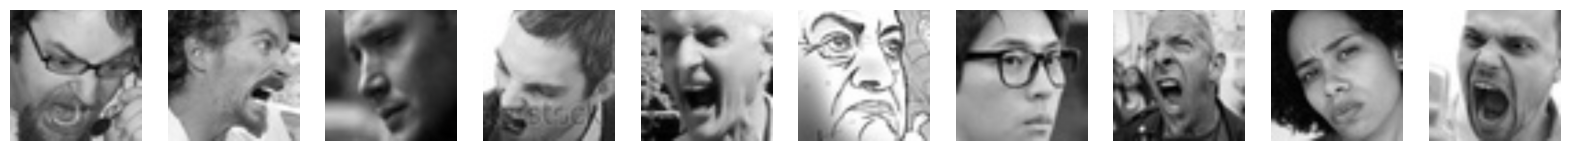

In [37]:
fig, axs = plt.subplots(1, 10, figsize=(20, 2))
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

for i in range(10):
    data, label = test_set[i]
    img = (data * std + mean).clamp(0, 1)
    axs[i].imshow(img.permute((1, 2, 0)))
    axs[i].axis('off')

In [38]:
train_loader = DataLoader(train_set, 
                          batch_size=args['batch_size'], 
                          shuffle=True)

val_loader = DataLoader(val_set,
                        batch_size=args['batch_size'],
                        shuffle=False)

test_loader = DataLoader(test_set, 
                         batch_size=args['batch_size'], 
                         shuffle=False)

In [39]:
# Pegando apenas um batch de dados
imagens, rotulos = next(iter(train_loader))

print(f"Formato do lote de imagens: {imagens.shape}")
print(f"Formato do lote de rótulos: {rotulos.shape}")
print(f"Primeiro rótulo do lote: {rotulos[0]}")

Formato do lote de imagens: torch.Size([32, 3, 224, 224])
Formato do lote de rótulos: torch.Size([32])
Primeiro rótulo do lote: 2


In [ ]:
# 1. Reset Total: ResNet18 da fábrica
net = models.resnet18(weights='DEFAULT')

# 2. Congela Tudo (Tranca a casa inteira)
for param in net.parameters():
    param.requires_grad = False

# 3. Descongela cirurgicamente Layer3 e Layer4
for param in net.layer3.parameters():
    param.requires_grad = True
for param in net.layer4.parameters():
    param.requires_grad = True

# 4. Cirurgia da Camada Final
num_features_in = net.fc.in_features
novo_features_out = 7
net.fc = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(num_features_in, novo_features_out)
)

# 5. Manda para a Placa de Vídeo
net = net.to(args['device'])

print(net)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
rotulos_treino = [train_set_aug.targets[i] for i in train_indices]
pesos_numpy = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(rotulos_treino),
    y=rotulos_treino
)
pesos_tensor = torch.tensor(pesos_numpy, dtype=torch.float).to(args['device'])

criterion = nn.CrossEntropyLoss(weight=pesos_tensor)

optimizer = optim.Adam([
    {'params': net.layer3.parameters(), 'lr': args['lr_layer3']},
    {'params': net.layer4.parameters(), 'lr': args['lr_layer4']},
    {'params': net.fc.parameters(), 'lr': args['lr_fc']}
], weight_decay=args['weight_decay'])

print("Pesos aplicados para cada emocao (em ordem):")
for classe, peso in zip(class_names, pesos_tensor):
    print(f"{classe}: {peso:.4f}")

Pesos aplicados para cada emocao (em ordem):
angry: 1.0265
disgust: 9.4162
fear: 1.0011
happy: 0.5685
neutral: 0.8259
sad: 0.8491
surprise: 1.2933


In [ ]:
def train(net, criterion, optimizer, train_loader, device):
    net.train()
    epoch_train_loss = []
    pred_list, rotulo_list = [], []
    
    for dado, rotulo in train_loader:
        dado, rotulo = dado.to(device), rotulo.to(device)
        
        ypred = net(dado)
        loss = criterion(ypred, rotulo)
        epoch_train_loss.append(loss.item())
        
        _, pred = torch.max(ypred, axis=1)
        pred_list.extend(pred.cpu().numpy())
        rotulo_list.extend(rotulo.cpu().numpy())
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        

    train_acc = accuracy_score(rotulo_list, pred_list)
    train_loss = np.mean(epoch_train_loss)

    return train_acc, train_loss

In [43]:
def validate(net, criterion, val_loader, device):
    net.eval()
    epoch_val_loss = []
    pred_list, rotulo_list = [], []

    with torch.no_grad():
        for dado, rotulo in val_loader:
            dado, rotulo = dado.to(device), rotulo.to(device)

            ypred = net(dado)
            loss = criterion(ypred, rotulo)
            epoch_val_loss.append(loss.item())
            
            _, pred = torch.max(ypred, axis=1)
            pred_list.extend(pred.cpu().numpy())
            rotulo_list.extend(rotulo.cpu().numpy())

    val_acc = accuracy_score(rotulo_list, pred_list)
    val_loss = np.mean(epoch_val_loss)

    return val_acc, val_loss

In [ ]:
nome_experimento = "resnet18_finetune_stratified_seed42"
os.makedirs('../models', exist_ok=True)
caminho_salvamento = f"../models/melhor_modelo_{nome_experimento}.pth"
caminho_metadata = f"../models/melhor_modelo_{nome_experimento}.json"

all_epoch_train_loss = []
all_epoch_train_acc = []
all_epoch_val_loss = []
all_epoch_val_acc = []

best_val_loss = float('inf')

print(f"Iniciando o treinamento por {args['num_epochs']} epocas...\n")

for epoch in range(args['num_epochs']):
    start_time = time.time()

    treino_acc, treino_loss = train(net, criterion, optimizer, train_loader, args['device'])
    val_acc, val_loss = validate(net, criterion, val_loader, args['device'])

    end_time = time.time()
    tempo_total = end_time - start_time

    all_epoch_train_loss.append(treino_loss)
    all_epoch_train_acc.append(treino_acc)
    all_epoch_val_loss.append(val_loss)
    all_epoch_val_acc.append(val_acc)

    print(f"Epoca {epoch+1}/{args['num_epochs']} | Tempo: {tempo_total:.0f}s")
    print(f"Treino - Loss: {treino_loss:.4f} | Acc: {treino_acc*100:.2f}%")
    print(f"Val    - Loss: {val_loss:.4f} | Acc: {val_acc*100:.2f}%\n")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(net.state_dict(), caminho_salvamento)
        print(f"[NOVO RECORDE] Val loss caiu para {best_val_loss:.4f}! Arquivo '{caminho_salvamento}' atualizado.")

metadata_modelo = {
    'architecture': 'resnet18',
    'num_classes': len(class_names),
    'class_names': class_names,
    'input_size': [224, 224],
    'normalize_mean': [0.485, 0.456, 0.406],
    'normalize_std': [0.229, 0.224, 0.225],
    'seed': args['seed']
}
with open(caminho_metadata, 'w', encoding='utf-8') as f:
    json.dump(metadata_modelo, f, ensure_ascii=False, indent=2)

print("Treinamento finalizado. Melhor checkpoint e metadados salvos em ../models.")

Iniciando o treinamento por 20 epocas...

Epoca 1/20 | Tempo: 76s
Treino - Loss: 1.5380 | Acc: 43.11%
Val    - Loss: 1.2918 | Acc: 50.19%

[NOVO RECORDE] Val loss caiu para 1.2918! Arquivo '../models/melhor_modelo_resnet18_finetune_stratified_seed42.pth' atualizado.
Epoca 2/20 | Tempo: 66s
Treino - Loss: 1.2528 | Acc: 53.28%
Val    - Loss: 1.2308 | Acc: 58.24%

[NOVO RECORDE] Val loss caiu para 1.2308! Arquivo '../models/melhor_modelo_resnet18_finetune_stratified_seed42.pth' atualizado.
Epoca 3/20 | Tempo: 63s
Treino - Loss: 1.1323 | Acc: 56.63%
Val    - Loss: 1.1324 | Acc: 60.99%

[NOVO RECORDE] Val loss caiu para 1.1324! Arquivo '../models/melhor_modelo_resnet18_finetune_stratified_seed42.pth' atualizado.
Epoca 4/20 | Tempo: 64s
Treino - Loss: 1.0574 | Acc: 59.39%
Val    - Loss: 1.1188 | Acc: 61.30%

[NOVO RECORDE] Val loss caiu para 1.1188! Arquivo '../models/melhor_modelo_resnet18_finetune_stratified_seed42.pth' atualizado.
Epoca 5/20 | Tempo: 67s
Treino - Loss: 0.9770 | Acc: 62.07

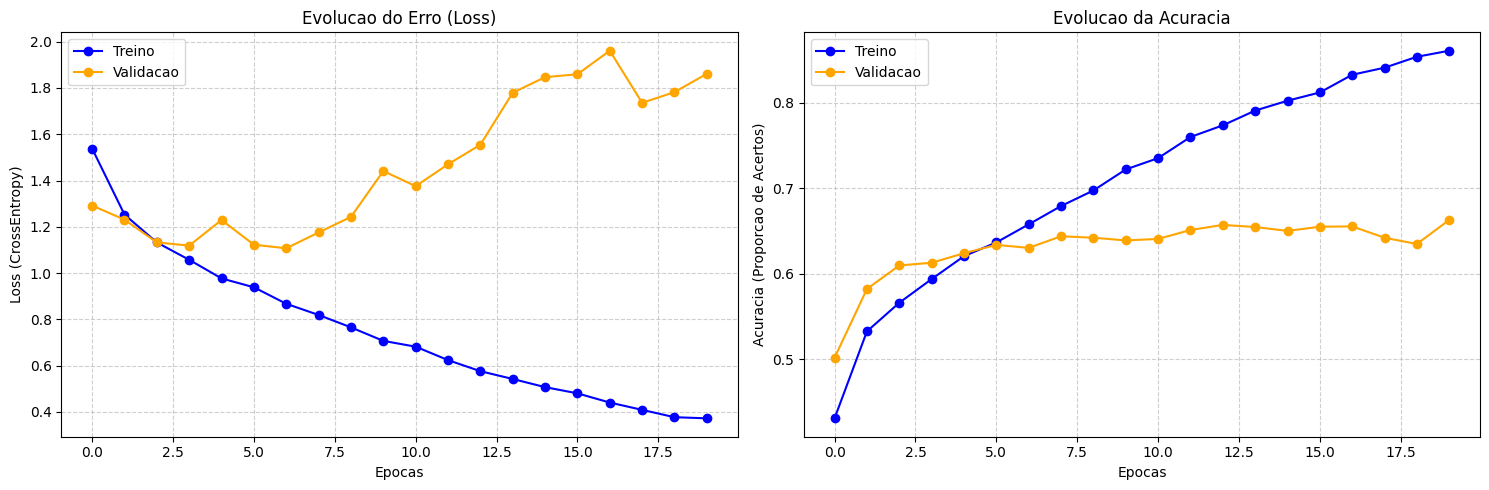

In [45]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

axs[0].plot(all_epoch_train_loss, label='Treino', color='blue', marker='o')
axs[0].plot(all_epoch_val_loss, label='Validacao', color='orange', marker='o')

axs[0].set_title('Evolucao do Erro (Loss)')
axs[0].set_xlabel('Epocas')
axs[0].set_ylabel('Loss (CrossEntropy)')
axs[0].legend()
axs[0].grid(True, linestyle='--', alpha=0.6)

axs[1].plot(all_epoch_train_acc, label='Treino', color='blue', marker='o')
axs[1].plot(all_epoch_val_acc, label='Validacao', color='orange', marker='o')

axs[1].set_title('Evolucao da Acuracia')
axs[1].set_xlabel('Epocas')
axs[1].set_ylabel('Acuracia (Proporcao de Acertos)')
axs[1].legend()
axs[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

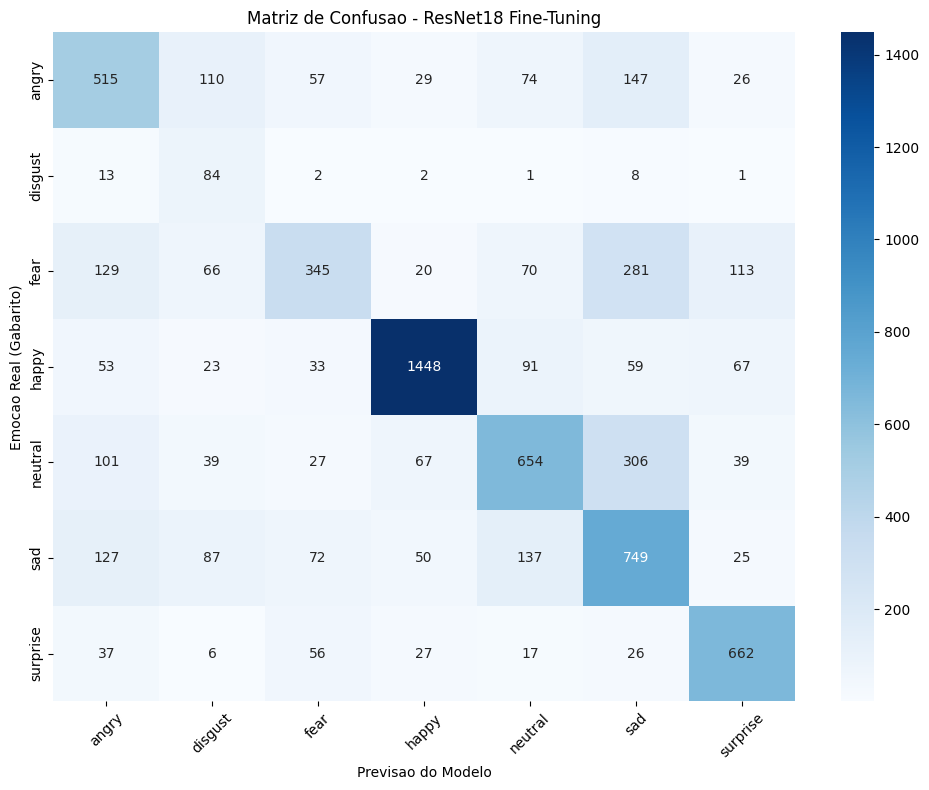

In [ ]:
nome_das_classes = class_names

# Garante que a avaliacao final use o melhor modelo salvo (val_loss minima)
net.load_state_dict(torch.load(caminho_salvamento, map_location=args['device']))
net = net.to(args['device'])

y_real = []
y_pred = []

net.eval()

with torch.no_grad():
    for dado, rotulo in test_loader:
        dado = dado.to(args['device'])

        saida = net(dado)

        _, previsao = torch.max(saida, axis=1)

        y_pred.extend(previsao.cpu().numpy())
        y_real.extend(rotulo.numpy())

matriz = confusion_matrix(y_real, y_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(matriz, 
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=nome_das_classes,
            yticklabels=nome_das_classes)
plt.title('Matriz de Confusao - ResNet18 Fine-Tuning')
plt.ylabel('Emocao Real (Gabarito)')
plt.xlabel('Previsao do Modelo')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()